In [12]:
import pandas as pd

recipe_classes_df = pd.read_csv("./input_stage2/recipe_classes.csv")
recipe_classes_df

,fdc_id,description,product,adj,verb,protein_g,fat_g,carb_g,energy_kcal,fiber_g,...,spicy,umami_rich,tangy_zesty,advanced_gourmet,one_pot_one_pan,generic,heat_level,cuisine_region,labels,n_labels
0,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...","['layer buttermilk biscuits', 'dough']","['Golden', 'Artificial']",['refrigerated'],5.88,13.2400,41.1800,307.0,1.2,...,0,0,0,0,0,0,none,NaN,comfort_food|kid_friendly,2
1,167516,"Waffles, buttermilk, frozen, ready-to-heat",['waffles'],['ready'],['frozen'],6.58,9.2200,41.0500,273.0,2.2,...,0,0,1,0,0,0,none,NaN,comfort_food|kid_friendly|tangy_zesty,3
2,167517,"Waffle, buttermilk, frozen, ready-to-heat, toa...",['waffle'],['ready'],"['frozen', 'toasted']",7.42,9.4900,48.3900,309.0,2.6,...,0,0,1,0,0,0,none,NaN,comfort_food|kid_friendly|tangy_zesty,3
3,167518,"Waffle, buttermilk, frozen, ready-to-heat, mic...",['waffle'],['ready'],"['frozen', 'microwaved']",6.92,9.4000,44.1600,289.0,2.4,...,0,0,1,0,0,0,none,NaN,comfort_food|kid_friendly|tangy_zesty,3
4,167519,"Waffle, plain, frozen, ready-to-heat, microwave",['waffle'],"['plain', 'ready']",['frozen'],6.71,9.9100,45.4100,298.0,2.4,...,0,0,0,0,0,0,none,NaN,comfort_food|kid_friendly,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10840,2710811,Vegetables as ingredient in soups,"['vegetables', 'soups']",[],[],1.87,0.3300,10.5600,50.0,2.0,...,0,0,0,0,0,1,none,NaN,generic,1
10841,2710812,Vegetables as ingredient in stews,"['vegetables', 'stews']",[],[],1.77,0.3000,12.6700,59.0,2.6,...,0,0,0,0,0,1,none,NaN,generic,1
10842,2710813,Sauce as ingredient in hamburgers,['sauce'],[],[],1.34,22.8500,17.1400,272.0,0.6,...,0,0,0,0,0,0,none,NaN,kid_friendly,1
10843,2710814,Industrial oil as ingredient in food,['oil'],['Industrial'],[],0.00,100.0000,0.0000,892.0,0.0,...,0,0,0,0,0,1,none,NaN,generic,1


## Label one-hot encoding

Targets come from the pipe-joined `labels` column (14 classes, incl. the exclusive `generic`); `fusion_cuisine` is dropped as too rare, leaving 13.
`heat_level` and `cuisine_region` are metadata, one-hot encoded separately (`cuisine_region` can hold several regions).

In [13]:
from sklearn.preprocessing import MultiLabelBinarizer

def split_pipe(s):
    return s.fillna("").apply(lambda v: [x for x in v.split("|") if x])

# multi-hot target matrix, one column per label
label_mlb = MultiLabelBinarizer()
Y = pd.DataFrame(
    label_mlb.fit_transform(split_pipe(recipe_classes_df["labels"])),
    columns=label_mlb.classes_,
    index=recipe_classes_df.index,
)
LABEL_COLS = list(label_mlb.classes_)

# `labels` must agree with the 0/1 columns written by recipe_labeling.ipynb
assert (Y == recipe_classes_df[LABEL_COLS]).all().all()
assert (Y.sum(axis=1) >= 1).all()
assert (Y.loc[Y["generic"] == 1].drop(columns="generic").sum(axis=1) == 0).all()

# fusion_cuisine is too rare (55 rows) to learn; drop it and mark rows left with no label as generic
DROPPED_LABELS = ["fusion_cuisine"]
Y = Y.drop(columns=DROPPED_LABELS)
Y.loc[Y.sum(axis=1) == 0, "generic"] = 1
LABEL_COLS = list(Y.columns)

heat_onehot = pd.get_dummies(recipe_classes_df["heat_level"], prefix="heat", dtype=int)

cuisine_mlb = MultiLabelBinarizer()
cuisine_onehot = pd.DataFrame(
    cuisine_mlb.fit_transform(split_pipe(recipe_classes_df["cuisine_region"])),
    columns=["cuisine_" + c for c in cuisine_mlb.classes_],
    index=recipe_classes_df.index,
)

print(Y.shape, heat_onehot.shape, cuisine_onehot.shape)
Y.sum().sort_values(ascending=False)

(10845, 13) (10845, 3) (10845, 13)


generic                5520
kid_friendly           2102
umami_rich             1785
comfort_food           1242
game_day_snack          714
weeknight_dinner        626
street_food_style       556
one_pot_one_pan         505
tangy_zesty             503
authentic_regional      299
advanced_gourmet        168
holiday_celebration     158
spicy                    99
dtype: int64

## Label balance

How skewed the 13 targets are before training: positives per label, prevalence, and imbalance vs the largest label (`generic`).

rows 10845, labels/row mean 1.32, max imbalance 56:1 (generic vs spicy)


,positives,prevalence_%,imbalance_vs_max
generic,5520,50.90,1.0
kid_friendly,2102,19.38,2.6
umami_rich,1785,16.46,3.1
comfort_food,1242,11.45,4.4
game_day_snack,714,6.58,7.7
weeknight_dinner,626,5.77,8.8
street_food_style,556,5.13,9.9
one_pot_one_pan,505,4.66,10.9
tangy_zesty,503,4.64,11.0
authentic_regional,299,2.76,18.5


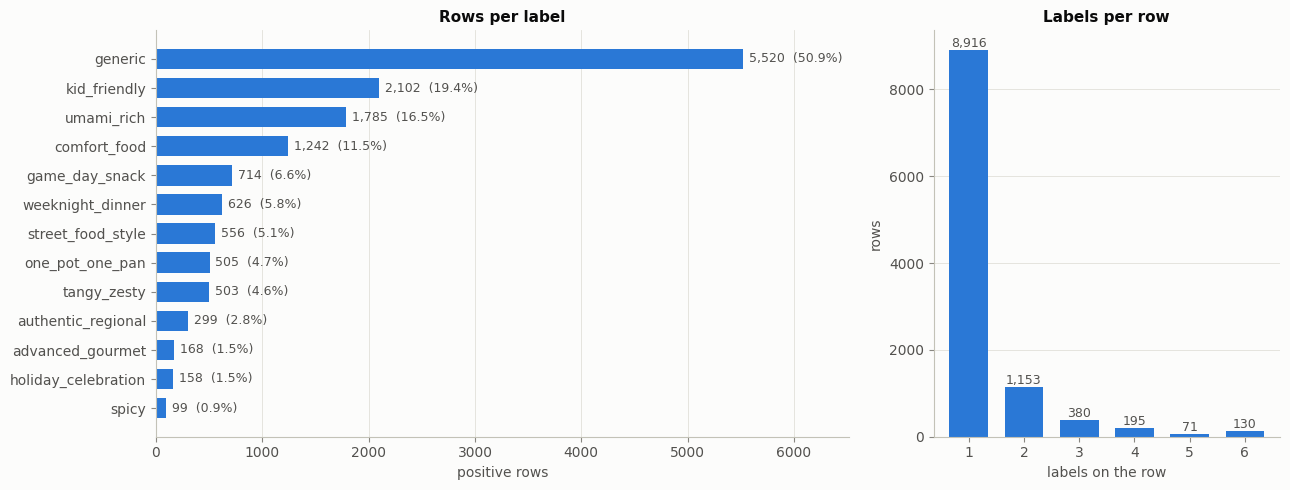

In [14]:
import matplotlib.pyplot as plt

# chart chrome (reference palette: light surface, recessive axes, categorical slots in fixed order)
SURFACE, INK, INK_2, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
SERIES = ["#2a78d6", "#eb6834"]
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": INK_2, "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})

label_counts = Y.sum().sort_values(ascending=False)
label_balance = pd.DataFrame({
    "positives": label_counts,
    "prevalence_%": (100 * label_counts / len(Y)).round(2),
    "imbalance_vs_max": (label_counts.max() / label_counts).round(1),
})
labels_per_row = Y.sum(axis=1)
print(f"rows {len(Y)}, labels/row mean {labels_per_row.mean():.2f}, "
      f"max imbalance {label_balance['imbalance_vs_max'].max():.0f}:1 "
      f"({label_counts.index[0]} vs {label_counts.index[-1]})")
display(label_balance)

fig, (ax_bal, ax_card) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [2, 1]})
order = label_counts.sort_values()
bars = ax_bal.barh(order.index, order.values, color=SERIES[0], height=0.7)
for bar, (name, cnt) in zip(bars, order.items()):
    ax_bal.text(bar.get_width() + label_counts.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{cnt:,}  ({100 * cnt / len(Y):.1f}%)", va="center", fontsize=9, color=INK_2)
ax_bal.set_xlim(0, label_counts.max() * 1.18)
ax_bal.grid(axis="y", visible=False)
ax_bal.set_xlabel("positive rows")
ax_bal.set_title("Rows per label")

card = labels_per_row.value_counts().sort_index()
ax_card.bar(card.index.astype(str), card.values, color=SERIES[0], width=0.7)
for x, v in zip(card.index.astype(str), card.values):
    ax_card.text(x, v, f"{v:,}", ha="center", va="bottom", fontsize=9, color=INK_2)
ax_card.grid(axis="x", visible=False)
ax_card.set_xlabel("labels on the row")
ax_card.set_ylabel("rows")
ax_card.set_title("Labels per row")
fig.tight_layout()
plt.show()

## Classifier chain over attention embeddings + nutrient PCA

```text
product / adj / verb terms ──MiniLM (frozen)──► self-attention within each item ──pool──► EMB_DIM vector ─┐
nutrients ──log1p──► StandardScaler ──► PCA (NUTRIENT_PCA_VARIANCE) ───────────────────────────────────────┴─► concat ──► ClassifierChain(LogisticRegression)
```

- Each item is its own attention sequence (padding is masked), so terms only attend to terms of the same item.
  A learned type embedding marks each term as product, adj or verb.
- The encoder is trained on the train-split labels (multi-label BCE head), then its pooled vectors are the item embeddings.
  One encoder embeds every row: out-of-fold encoders would each learn their own embedding space, which the chain cannot
  combine. Encoder, scaler, PCA and chain are fit on the train split only.
- Rare labels (e.g. `spicy`, 99 rows) are handled by `class_weight="balanced"` in each chain link and `pos_weight` in the encoder loss.
- Caveat: the silver labels were produced by rules over the same description/product/adj/verb text and nutrient thresholds,
  so these scores measure how well the rules are recovered, not true label quality.

In [15]:
import ast
import random

import numpy as np
import torch
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, hamming_loss, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.multioutput import ClassifierChain
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.nn import functional as F

RANDOM_STATE = 42
TEST_SIZE = 0.2
TERM_MODEL = "sentence-transformers/all-MiniLM-L6-v2"  # Frozen vector per product / adj / verb term.
TERM_REVISION = "1110a243fdf4706b3f48f1d95db1a4f5529b4d41"
TOKEN_TYPES = ["product", "adj", "verb"]
EMB_DIM = 64
ATTENTION_HEADS = 4
ENCODER_EPOCHS = 20
ENCODER_BATCH_SIZE = 256
ENCODER_LR = 1e-3
MAX_POS_WEIGHT = 50.0
NUTRIENT_COLS = ["protein_g", "fat_g", "carb_g", "energy_kcal", "fiber_g", "sodium_mg",
                 "cholesterol_mg", "satfat_g", "sugars_g"]
NUTRIENT_PCA_VARIANCE = 0.95

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

In [16]:
# ---------- terms per item ----------
def parse_terms(col):
    return recipe_classes_df[col].fillna("[]").apply(ast.literal_eval).apply(
        lambda xs: [str(x).strip().lower() for x in xs if str(x).strip()])

item_terms = []  # per item: list of (term, type index)
for row in zip(*(parse_terms(c) for c in TOKEN_TYPES)):
    item_terms.append([(t, k) for k, terms in enumerate(row) for t in terms])

vocab = sorted({t for terms in item_terms for t, _ in terms})
term_index = {t: i + 1 for i, t in enumerate(vocab)}  # 0 = padding
term_model = SentenceTransformer(TERM_MODEL, revision=TERM_REVISION, device="cpu")
term_vectors = term_model.encode(vocab, batch_size=256, normalize_embeddings=True, show_progress_bar=False)
term_vectors = np.vstack([np.zeros((1, term_vectors.shape[1]), dtype=np.float32), term_vectors])

max_len = max(len(terms) for terms in item_terms)
term_ids = np.zeros((len(item_terms), max_len), dtype=np.int64)
type_ids = np.zeros((len(item_terms), max_len), dtype=np.int64)
for i, terms in enumerate(item_terms):
    for j, (t, k) in enumerate(terms):
        term_ids[i, j] = term_index[t]
        type_ids[i, j] = k
assert (term_ids[:, 0] > 0).all()  # every item has at least one term
print(f"{len(vocab)} terms, max {max_len} per item")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

2977 terms, max 14 per item


In [17]:
class ItemAttentionEncoder(nn.Module):
    """Self-attention over one item's product/adj/verb terms, masked-mean pooled to EMB_DIM."""

    def __init__(self, term_vectors, n_labels):
        super().__init__()
        self.term_emb = nn.Embedding.from_pretrained(torch.tensor(term_vectors), freeze=True, padding_idx=0)
        self.proj = nn.Linear(term_vectors.shape[1], EMB_DIM)
        self.type_emb = nn.Embedding(len(TOKEN_TYPES), EMB_DIM)
        self.attn = nn.MultiheadAttention(EMB_DIM, ATTENTION_HEADS, dropout=0.1, batch_first=True)
        self.norm1 = nn.LayerNorm(EMB_DIM)
        self.ff = nn.Sequential(nn.Linear(EMB_DIM, 2 * EMB_DIM), nn.GELU(), nn.Linear(2 * EMB_DIM, EMB_DIM))
        self.norm2 = nn.LayerNorm(EMB_DIM)
        self.head = nn.Linear(EMB_DIM, n_labels)

    def embed(self, term_ids, type_ids):
        pad = term_ids == 0
        x = self.proj(self.term_emb(term_ids)) + self.type_emb(type_ids)
        a, _ = self.attn(x, x, x, key_padding_mask=pad)  # a term only sees terms of its own item
        x = self.norm1(x + a)
        x = self.norm2(x + self.ff(x))
        keep = (~pad).unsqueeze(-1).float()
        return (x * keep).sum(1) / keep.sum(1)

    def forward(self, term_ids, type_ids):
        return self.head(self.embed(term_ids, type_ids))


def fit_encoder(idx, Y_np):
    model = ItemAttentionEncoder(term_vectors, Y_np.shape[1])
    y = torch.tensor(Y_np[idx], dtype=torch.float32)
    pos = y.sum(0)
    pos_weight = ((len(y) - pos) / pos.clamp(min=1)).clamp(max=MAX_POS_WEIGHT)
    terms, types = torch.tensor(term_ids[idx]), torch.tensor(type_ids[idx])
    opt = torch.optim.AdamW(model.parameters(), lr=ENCODER_LR, weight_decay=1e-4)
    model.train()
    for epoch in range(ENCODER_EPOCHS):
        perm = torch.randperm(len(idx))
        for b in range(0, len(idx), ENCODER_BATCH_SIZE):
            bi = perm[b:b + ENCODER_BATCH_SIZE]
            loss = F.binary_cross_entropy_with_logits(model(terms[bi], types[bi]), y[bi], pos_weight=pos_weight)
            opt.zero_grad()
            loss.backward()
            opt.step()
    return model.eval()


@torch.no_grad()
def encode(model, idx):
    return model.embed(torch.tensor(term_ids[idx]), torch.tensor(type_ids[idx])).numpy()

In [18]:
# ---------- split + item embeddings ----------
Y_np = Y[LABEL_COLS].to_numpy()
train_idx, test_idx = train_test_split(np.arange(len(Y_np)), test_size=TEST_SIZE, random_state=RANDOM_STATE)

encoder = fit_encoder(train_idx, Y_np)
item_emb = encode(encoder, np.arange(len(Y_np)))

In [19]:
# ---------- label balance across the split: rare labels must still have test positives ----------
split_balance = pd.DataFrame({
    "train_%": (100 * Y_np[train_idx].mean(0)).round(2),
    "test_%": (100 * Y_np[test_idx].mean(0)).round(2),
    "test_positives": Y_np[test_idx].sum(0),
}, index=LABEL_COLS).sort_values("test_positives")
split_balance["diff_pp"] = (split_balance["test_%"] - split_balance["train_%"]).round(2)
display(split_balance)

,train_%,test_%,test_positives,diff_pp
spicy,0.93,0.83,18,-0.10
holiday_celebration,1.43,1.57,34,0.14
advanced_gourmet,1.45,1.94,42,0.49
authentic_regional,2.65,3.18,69,0.53
street_food_style,5.23,4.70,102,-0.53
one_pot_one_pan,4.60,4.89,106,0.29
tangy_zesty,4.55,4.98,108,0.43
weeknight_dinner,5.83,5.53,120,-0.30
game_day_snack,6.71,6.09,132,-0.62
comfort_food,11.55,11.07,240,-0.48


In [20]:
# ---------- nutrients: log1p (heavy right tail, e.g. sodium up to 38,758 mg) → standardize → PCA ----------
nutrients = np.log1p(recipe_classes_df[NUTRIENT_COLS].clip(lower=0))
nutrients = nutrients.fillna(nutrients.iloc[train_idx].median()).to_numpy()

nutrient_scaler = StandardScaler().fit(nutrients[train_idx])
nutrient_pca = PCA(n_components=NUTRIENT_PCA_VARIANCE, random_state=RANDOM_STATE).fit(
    nutrient_scaler.transform(nutrients[train_idx]))
nutrient_pcs = nutrient_pca.transform(nutrient_scaler.transform(nutrients))
print(f"{nutrient_pca.n_components_} PCs, explained variance {nutrient_pca.explained_variance_ratio_.sum():.3f}")

6 PCs, explained variance 0.961


## Nutrient variance before / after standardization

Raw nutrients sit on very different scales (sodium in mg vs fiber in g), so without scaling PCA would just follow sodium.
log1p tames the right tail; `StandardScaler` then gives every nutrient mean 0 / variance 1 on the train rows.

,raw_var,log1p_var,standardized_var,standardized_mean,raw_share_%
protein_g,102.2,1.084,1.000,1.5e-16,0.01
fat_g,235.8,1.301,1.000,1.9e-15,0.03
carb_g,551.9,2.207,1.000,8.1e-15,0.07
energy_kcal,"26,189.0",0.981,1.000,-1.1e-14,3.41
fiber_g,13.6,0.559,1.000,-8.3e-15,0.00
sodium_mg,"727,226.3",3.073,1.000,1.1e-14,94.76
cholesterol_mg,"12,951.3",3.969,1.000,-4.0e-15,1.69
satfat_g,35.4,0.706,1.000,-6.7e-16,0.00
sugars_g,147.7,1.171,1.000,4.4e-15,0.02


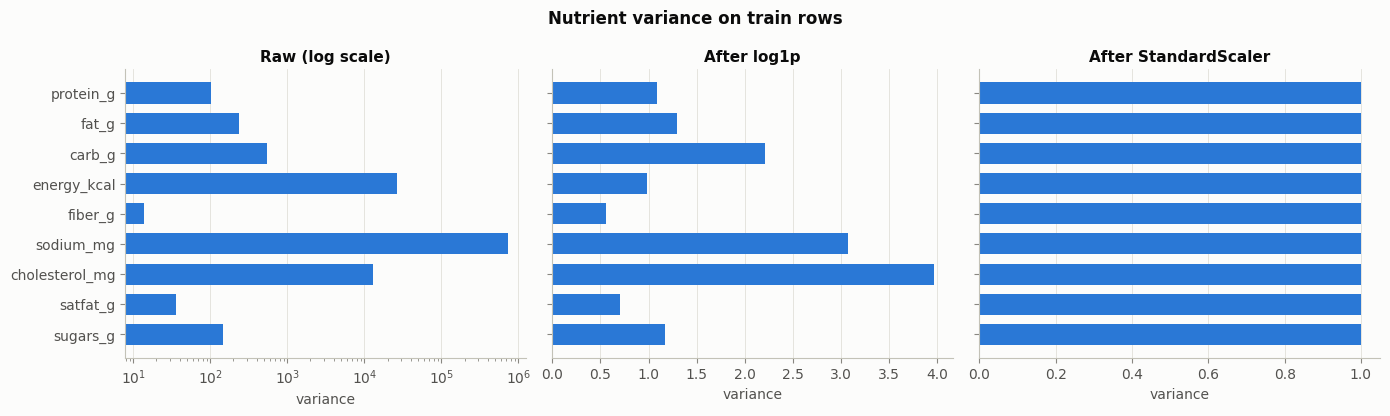

In [21]:
nutrients_raw = recipe_classes_df[NUTRIENT_COLS].iloc[train_idx]
nutrients_log = nutrients[train_idx]                    # after log1p + median fill
nutrients_std = nutrient_scaler.transform(nutrients_log)  # after StandardScaler

nutrient_variance = pd.DataFrame({
    "raw_var": nutrients_raw.var(ddof=0),
    "log1p_var": nutrients_log.var(0),
    "standardized_var": nutrients_std.var(0),
    "standardized_mean": nutrients_std.mean(0),
}, index=NUTRIENT_COLS)
nutrient_variance["raw_share_%"] = 100 * nutrient_variance["raw_var"] / nutrient_variance["raw_var"].sum()
display(nutrient_variance.style.format({
    "raw_var": "{:,.1f}", "log1p_var": "{:.3f}", "standardized_var": "{:.3f}",
    "standardized_mean": "{:.1e}", "raw_share_%": "{:.2f}"}))
assert np.allclose(nutrients_std.var(0), 1, atol=1e-6) and np.allclose(nutrients_std.mean(0), 0, atol=1e-6)

# one panel per stage: the stages differ by orders of magnitude, so they never share an axis
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
stages = [("raw_var", "Raw (log scale)"), ("log1p_var", "After log1p"), ("standardized_var", "After StandardScaler")]
for ax, (col, title) in zip(axes, stages):
    ax.barh(NUTRIENT_COLS, nutrient_variance[col], color=SERIES[0], height=0.7)
    ax.set_title(title)
    ax.set_xlabel("variance")
    ax.grid(axis="y", visible=False)
axes[0].set_xscale("log")
axes[0].invert_yaxis()
fig.suptitle("Nutrient variance on train rows", color=INK, fontweight="bold")
fig.tight_layout()
plt.show()

## Nutrient PCA

Scree (how much variance each component keeps; the kept ones are those needed for `NUTRIENT_PCA_VARIANCE`),
the first two components colored by generic vs labelled items, and the loadings of the kept components.

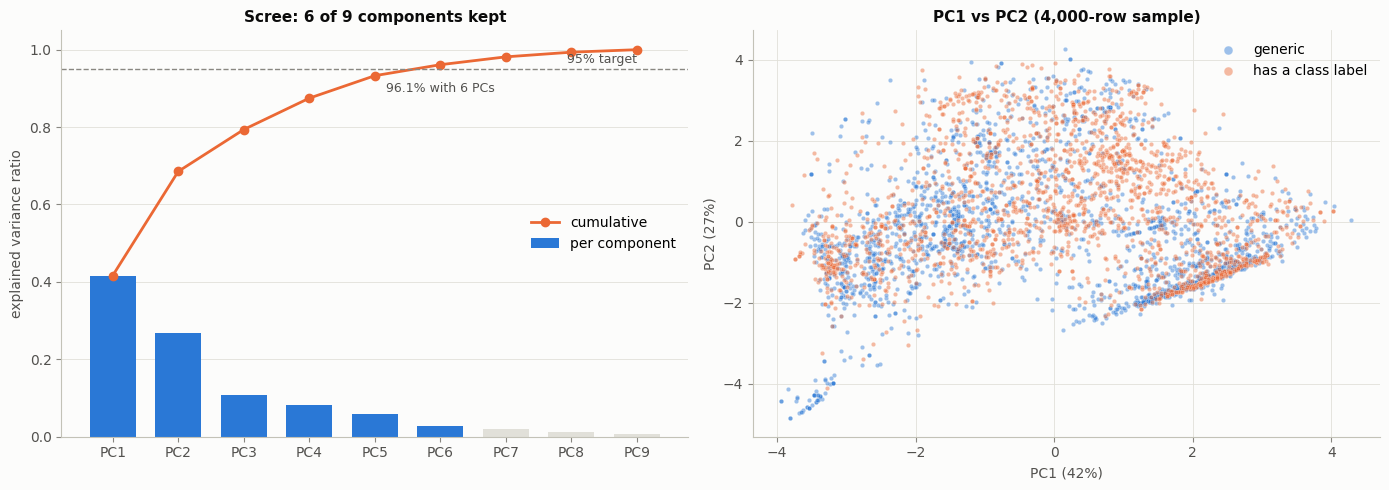

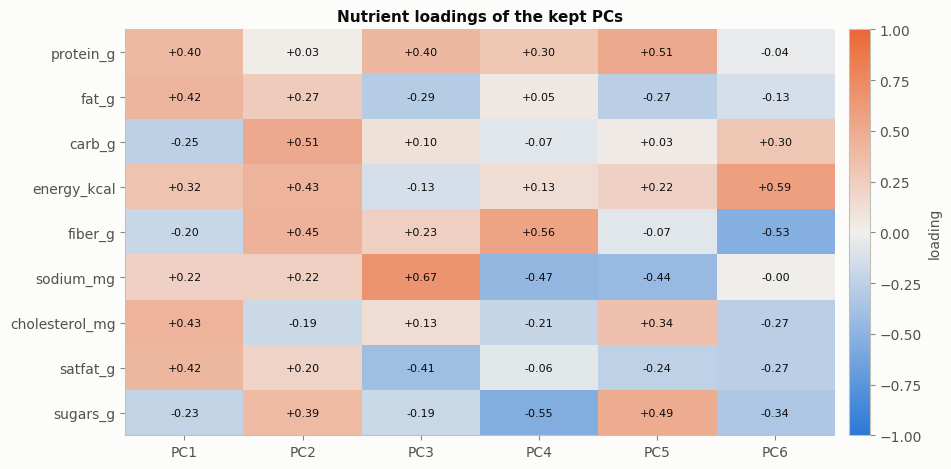

In [22]:
from matplotlib.colors import LinearSegmentedColormap

pca_full = PCA(random_state=RANDOM_STATE).fit(nutrients_std)  # all components, only for the scree plot
evr = pca_full.explained_variance_ratio_
k = nutrient_pca.n_components_
pc_names = [f"PC{i + 1}" for i in range(len(evr))]

fig, (ax_scree, ax_scatter) = plt.subplots(1, 2, figsize=(14, 5))
ax_scree.bar(pc_names, evr, color=[SERIES[0] if i < k else GRID for i in range(len(evr))], width=0.7,
             label="per component")
ax_scree.plot(pc_names, np.cumsum(evr), color=SERIES[1], lw=2, marker="o", ms=6, label="cumulative")
ax_scree.axhline(NUTRIENT_PCA_VARIANCE, color=MUTED, lw=1, ls="--")
ax_scree.text(len(evr) - 1, NUTRIENT_PCA_VARIANCE + 0.015, f"{NUTRIENT_PCA_VARIANCE:.0%} target",
              ha="right", fontsize=9, color=INK_2)
ax_scree.annotate(f"{np.cumsum(evr)[k - 1]:.1%} with {k} PCs", (k - 1, np.cumsum(evr)[k - 1]),
                  xytext=(0, -20), textcoords="offset points", ha="center", fontsize=9, color=INK_2)
ax_scree.set_ylim(0, 1.05)
ax_scree.set_ylabel("explained variance ratio")
ax_scree.grid(axis="x", visible=False)
ax_scree.legend(loc="center right")
ax_scree.set_title(f"Scree: {k} of {len(evr)} components kept")

rng = np.random.default_rng(RANDOM_STATE)
sample = rng.choice(len(nutrient_pcs), size=min(4000, len(nutrient_pcs)), replace=False)
is_generic = Y["generic"].to_numpy()[sample] == 1
for mask, name, color in [(is_generic, "generic", SERIES[0]), (~is_generic, "has a class label", SERIES[1])]:
    ax_scatter.scatter(nutrient_pcs[sample][mask, 0], nutrient_pcs[sample][mask, 1], s=10, alpha=0.45,
                       color=color, edgecolors=SURFACE, linewidths=0.3, label=name)
ax_scatter.set_xlabel(f"PC1 ({evr[0]:.0%})")
ax_scatter.set_ylabel(f"PC2 ({evr[1]:.0%})")
ax_scatter.legend(markerscale=2)
ax_scatter.set_title("PC1 vs PC2 (4,000-row sample)")
fig.tight_layout()
plt.show()

# loadings of the kept components: diverging blue / neutral / orange, centred on 0
diverging = LinearSegmentedColormap.from_list("div", [SERIES[0], "#f0efec", SERIES[1]])
loadings = pd.DataFrame(nutrient_pca.components_.T, index=NUTRIENT_COLS, columns=pc_names[:k])
fig, ax = plt.subplots(figsize=(1.1 * k + 3, 4.8))
im = ax.imshow(loadings.values, cmap=diverging, vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(k), loadings.columns)
ax.set_yticks(range(len(NUTRIENT_COLS)), NUTRIENT_COLS)
ax.grid(False)
for (i, j), v in np.ndenumerate(loadings.values):
    ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8, color=INK)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label="loading")
ax.set_title("Nutrient loadings of the kept PCs")
fig.tight_layout()
plt.show()

In [23]:
# ---------- concat → classifier chain ----------
X = np.hstack([item_emb, nutrient_pcs])
feature_scaler = StandardScaler().fit(X[train_idx])
X = feature_scaler.transform(X)

chain_order = np.argsort(-Y_np[train_idx].sum(0))  # most frequent label first
chain = ClassifierChain(
    LogisticRegression(class_weight="balanced", max_iter=2000),
    order=chain_order,
    random_state=RANDOM_STATE,
).fit(X[train_idx], Y_np[train_idx])

Y_pred = chain.predict(X[test_idx]).astype(int)
Y_true = Y_np[test_idx]
print(f"X: {X.shape}  (item embedding {EMB_DIM} + nutrient PCs {nutrient_pcs.shape[1]})")
print(f"micro F1 {f1_score(Y_true, Y_pred, average='micro'):.3f}  "
      f"macro F1 {f1_score(Y_true, Y_pred, average='macro'):.3f}  "
      f"hamming loss {hamming_loss(Y_true, Y_pred):.3f}  "
      f"exact match {accuracy_score(Y_true, Y_pred):.3f}")
print(classification_report(Y_true, Y_pred, target_names=LABEL_COLS, zero_division=0))

X: (10845, 70)  (item embedding 64 + nutrient PCs 6)
micro F1 0.697  macro F1 0.577  hamming loss 0.071  exact match 0.581
                     precision    recall  f1-score   support

   advanced_gourmet       0.32      0.71      0.44        42
 authentic_regional       0.33      0.62      0.43        69
       comfort_food       0.48      0.80      0.61       240
     game_day_snack       0.55      0.85      0.67       132
            generic       0.82      0.84      0.83      1091
holiday_celebration       0.36      0.59      0.44        34
       kid_friendly       0.72      0.89      0.80       398
    one_pot_one_pan       0.39      0.75      0.52       106
              spicy       0.23      0.56      0.32        18
  street_food_style       0.47      0.96      0.63       102
        tangy_zesty       0.47      0.60      0.53       108
         umami_rich       0.55      0.79      0.65       354
   weeknight_dinner       0.49      0.91      0.63       120

          micro avg  

## Save weights

`model_artifacts/recipe_classifier/`:
- `recipe_classifier.pt`: attention encoder `state_dict`, term vocabulary + frozen MiniLM term vectors, encoder config.
- `preprocessing.joblib`: nutrient train medians, nutrient scaler, PCA, feature scaler, classifier chain.
- `config.json`: label order, dropped labels, settings and test metrics.

The last lines reload the files and check they reproduce the test predictions.

In [24]:
import json
from pathlib import Path

import joblib

ARTIFACT_DIR = Path("model_artifacts/recipe_classifier")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

encoder_config = {"emb_dim": EMB_DIM, "attention_heads": ATTENTION_HEADS, "token_types": TOKEN_TYPES,
                  "max_len": max_len, "n_labels": len(LABEL_COLS)}
torch.save({"state_dict": {k: v.detach().cpu() for k, v in encoder.state_dict().items()},
            "encoder_config": encoder_config, "vocab": vocab, "term_vectors": term_vectors},
           ARTIFACT_DIR / "recipe_classifier.pt")
joblib.dump({"nutrient_cols": NUTRIENT_COLS,
             "nutrient_medians": np.log1p(recipe_classes_df[NUTRIENT_COLS].clip(lower=0)).iloc[train_idx].median(),
             "nutrient_scaler": nutrient_scaler, "nutrient_pca": nutrient_pca,
             "feature_scaler": feature_scaler, "chain": chain},
            ARTIFACT_DIR / "preprocessing.joblib")
(ARTIFACT_DIR / "config.json").write_text(json.dumps({
    "label_cols": LABEL_COLS, "dropped_labels": DROPPED_LABELS, "chain_order": chain_order.tolist(),
    "term_model": TERM_MODEL, "term_revision": TERM_REVISION, "random_state": RANDOM_STATE, "test_size": TEST_SIZE,
    "encoder_epochs": ENCODER_EPOCHS, "encoder_lr": ENCODER_LR, "nutrient_pca_variance": NUTRIENT_PCA_VARIANCE,
    "test_metrics": {"micro_f1": f1_score(Y_true, Y_pred, average="micro"),
                     "macro_f1": f1_score(Y_true, Y_pred, average="macro"),
                     "hamming_loss": hamming_loss(Y_true, Y_pred),
                     "exact_match": accuracy_score(Y_true, Y_pred)},
}, indent=2))

# reload and check the saved files reproduce the test predictions
saved = torch.load(ARTIFACT_DIR / "recipe_classifier.pt", weights_only=False)
reloaded = ItemAttentionEncoder(saved["term_vectors"], saved["encoder_config"]["n_labels"])
reloaded.load_state_dict(saved["state_dict"])
reloaded.eval()
prep = joblib.load(ARTIFACT_DIR / "preprocessing.joblib")
with torch.no_grad():
    emb = reloaded.embed(torch.tensor(term_ids[test_idx]), torch.tensor(type_ids[test_idx])).numpy()
nut = np.log1p(recipe_classes_df[NUTRIENT_COLS].clip(lower=0)).iloc[test_idx].fillna(prep["nutrient_medians"]).to_numpy()
pcs = prep["nutrient_pca"].transform(prep["nutrient_scaler"].transform(nut))
X_re = prep["feature_scaler"].transform(np.hstack([emb, pcs]))
assert (prep["chain"].predict(X_re).astype(int) == Y_pred).all()
print("saved to", ARTIFACT_DIR, sorted(p.name for p in ARTIFACT_DIR.iterdir()))

saved to model_artifacts/recipe_classifier ['config.json', 'preprocessing.joblib', 'recipe_classifier.pt']
